# Import Libraries

In [1]:
import os
import json
import csv
import random
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd  # Often useful with CSVs
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Computer Vision
import cv2

# Scikit-Learn (Metrics & Preprocessing)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, confusion_matrix, 
    classification_report, mean_absolute_error, 
    mean_squared_error, r2_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Concatenate, Layer

In [2]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Data Loading

In [3]:
Dataset_path = "Data" 
IMG_SIZE = 224

In [4]:
def load_dataset(Dataset_path):
    X_palm, X_nail, X_meta = [], [], []
    y_label                 = []
    subject_ids             = []

    root     = Path(Dataset_path)
    subjects = [p for p in root.iterdir() if p.is_dir()]

    for s in subjects:
        json_path = s / "info.json"
        if not json_path.exists():
            continue
        with open(json_path, "r") as f:
            info = json.load(f)

        age    = info["age"]
        gender = 1 if info["gender"] == "Male" else 0
        label  = 1 if info["label"]  == "Anemic" else 0

        # Palm ROI
        palm_path = s / "Palm_ROI" / "frame_03.jpg"
        if not palm_path.exists():
            continue
        palm_img = cv2.imread(str(palm_path))
        if palm_img is None:
            continue
        palm_img = cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB)
        palm_img = cv2.resize(palm_img, (IMG_SIZE, IMG_SIZE))
        palm_img = palm_img / 255.0

        # Nail ROI
        nail_path = s / "nail_roi.jpg"
        if not nail_path.exists():
            continue
        nail_img = cv2.imread(str(nail_path))
        if nail_img is None:
            continue
        
        nail_img = cv2.cvtColor(nail_img, cv2.COLOR_BGR2RGB)
        nail_img = cv2.resize(nail_img, (IMG_SIZE, IMG_SIZE))
        nail_img = nail_img / 255.0

        X_palm.append(palm_img)
        X_nail.append(nail_img)
        X_meta.append([age, gender])
        y_label.append(label)
        subject_ids.append(s.name)

    return (
        np.array(X_palm,  dtype=np.float32),
        np.array(X_nail,  dtype=np.float32),
        np.array(X_meta,  dtype=np.float32),
        np.array(y_label, dtype=np.int32),
        np.array(subject_ids)
    )

In [5]:
X_palm, X_nail, X_meta, y_label, subject_ids = load_dataset(Dataset_path)

In [6]:
print(f"Total patients : {len(subject_ids)}")
print(f"Anemic         : {sum(y_label == 1)}")
print(f"Non-Anemic     : {sum(y_label == 0)}")

Total patients : 527
Anemic         : 264
Non-Anemic     : 263


In [7]:
# Train-Test Split
unique_subjects = np.unique(subject_ids)
unique_labels   = np.array([y_label[subject_ids == s][0] for s in unique_subjects])

train_subj, temp_subj = train_test_split(
    unique_subjects, test_size=0.30, random_state=42, stratify=unique_labels
)
temp_labels = np.array([y_label[subject_ids == s][0] for s in temp_subj])
val_subj, test_subj = train_test_split(
    temp_subj, test_size=0.50, random_state=42, stratify=temp_labels
)

train_idx = np.where(np.isin(subject_ids, train_subj))[0]
val_idx   = np.where(np.isin(subject_ids, val_subj))[0]
test_idx  = np.where(np.isin(subject_ids, test_subj))[0]

X_palm_train, X_palm_val, X_palm_test = X_palm[train_idx], X_palm[val_idx], X_palm[test_idx]
X_nail_train, X_nail_val, X_nail_test = X_nail[train_idx], X_nail[val_idx], X_nail[test_idx]
X_meta_train, X_meta_val, X_meta_test = X_meta[train_idx], X_meta[val_idx], X_meta[test_idx]
y_label_train, y_label_val, y_label_test = y_label[train_idx], y_label[val_idx], y_label[test_idx]

print(f"\nTrain : {len(train_subj)} patients")
print(f"Val   : {len(val_subj)}   patients")
print(f"Test  : {len(test_subj)}  patients")
print(f"\nTrain → Anemic: {sum(y_label_train==1)}, Non-Anemic: {sum(y_label_train==0)}")
print(f"Val   → Anemic: {sum(y_label_val==1)},   Non-Anemic: {sum(y_label_val==0)}")
print(f"Test  → Anemic: {sum(y_label_test==1)},  Non-Anemic: {sum(y_label_test==0)}")



Train : 368 patients
Val   : 79   patients
Test  : 80  patients

Train → Anemic: 184, Non-Anemic: 184
Val   → Anemic: 40,   Non-Anemic: 39
Test  → Anemic: 40,  Non-Anemic: 40


In [8]:
scaler = StandardScaler()
scaler.fit(X_meta_train[:, 0:1])

# Transform all splits using training mean/std
X_meta_train[:, 0:1] = scaler.transform(X_meta_train[:, 0:1])
X_meta_val[:, 0:1]   = scaler.transform(X_meta_val[:, 0:1])
X_meta_test[:, 0:1]  = scaler.transform(X_meta_test[:, 0:1])


print("Age mean (train):", scaler.mean_[0])
print("Age std (train):", scaler.scale_[0])

Age mean (train): 20.266304347826086
Age std (train): 2.3899143687548925


# Data Augmentation

In [9]:
from Augmentation import augment_training_set, augment_image

In [10]:
print("\nBefore Augmentation:")
print(f"  Train size  : {len(y_label_train)}")
print(f"  Anemic      : {sum(y_label_train==1)}")
print(f"  Non-Anemic  : {sum(y_label_train==0)}")

X_palm_train, X_nail_train, X_meta_train, y_label_train = augment_training_set(
    X_palm_train, X_nail_train, X_meta_train, y_label_train
)

print(f"\nAfter Augmentation (1 original + 4 fixed augmentations):")
print(f"  Train size  : {len(y_label_train)}")
print(f"  Anemic      : {sum(y_label_train==1)}")
print(f"  Non-Anemic  : {sum(y_label_train==0)}")
print(f"Val  size     : {len(y_label_val)}")
print(f"Test size     : {len(y_label_test)}")


Before Augmentation:
  Train size  : 368
  Anemic      : 184
  Non-Anemic  : 184

After Augmentation (1 original + 4 fixed augmentations):
  Train size  : 1840
  Anemic      : 920
  Non-Anemic  : 920
Val  size     : 79
Test size     : 80


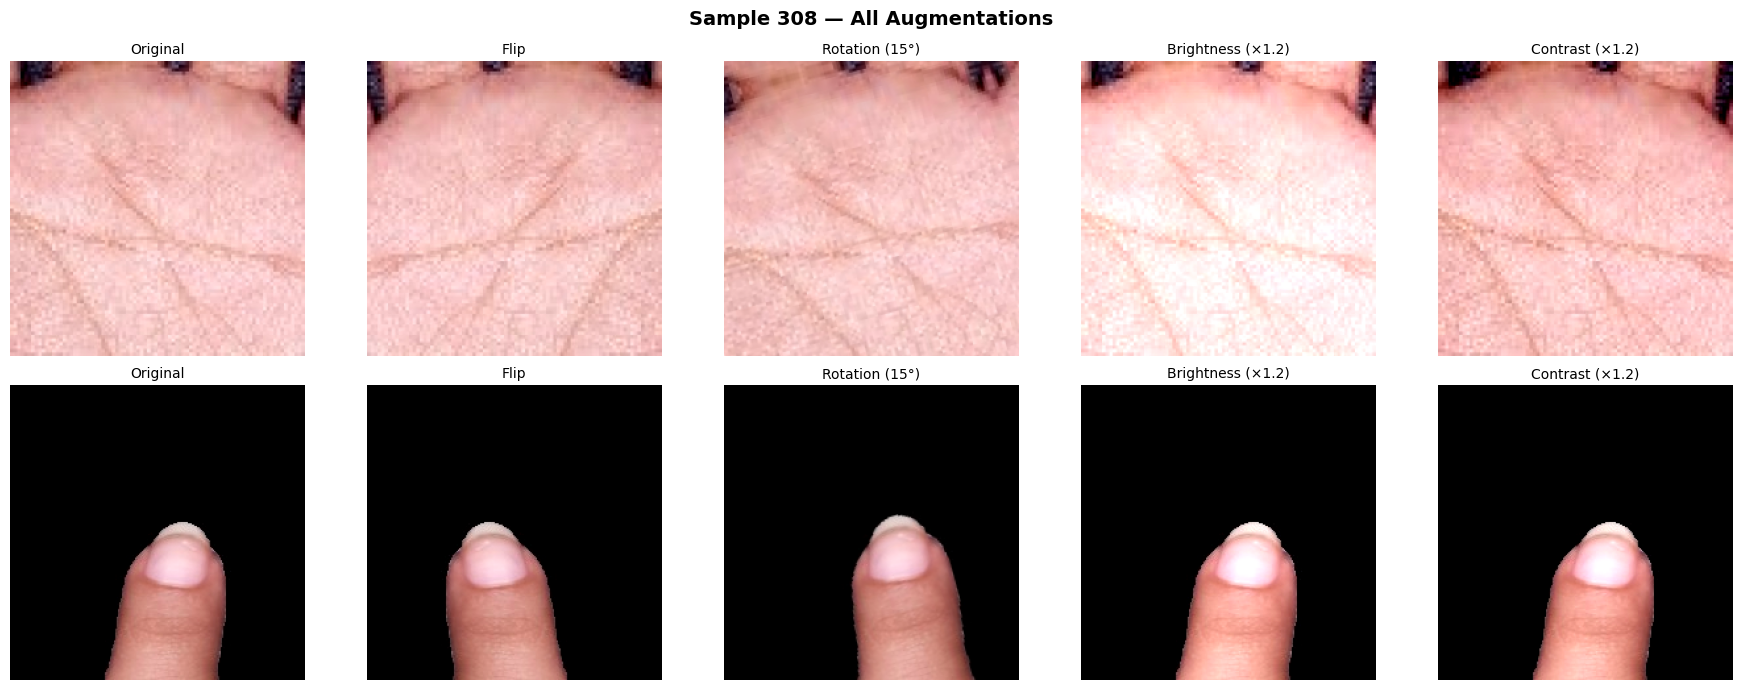

In [11]:
def visualise_one_sample(X_palm, X_nail, idx=None):
    if idx is None:
        idx = np.random.randint(0, len(X_palm))
    
    img_palm = (X_palm[idx] * 255).astype(np.uint8)
    img_nail = (X_nail[idx] * 255).astype(np.uint8)
    
    titles = ['Original', 'Flip', 'Rotation (15°)', 'Brightness (×1.2)', 'Contrast (×1.2)']
    
    palm_imgs = [img_palm] + [(a * 255).astype(np.uint8) for a in augment_image (X_palm[idx])]
    nail_imgs = [img_nail] + [(a * 255).astype(np.uint8) for a in augment_image (X_nail[idx])]
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(f'Sample {idx} — All Augmentations', fontsize=14, fontweight='bold')
    
    for col in range(5):
        axes[0, col].imshow(palm_imgs[col])
        axes[0, col].set_title(titles[col], fontsize=10)
        axes[0, col].axis('off')
        
        axes[1, col].imshow(nail_imgs[col])
        axes[1, col].set_title(titles[col], fontsize=10)
        axes[1, col].axis('off')
    
    axes[0, 0].set_ylabel('Palm', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Nail', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

visualise_one_sample(X_palm_train, X_nail_train)

# Models - Experimentation

In [12]:
import importlib
import Backbones, Attention, Build

importlib.reload(Backbones)
importlib.reload(Attention)
importlib.reload(Build)

from Build import build_models

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        mode="min",
        factor=0.5,
        min_lr=1e-6
    )
]

In [14]:
def evaluate_model(name, model, history):

    val_scores  = model.evaluate([X_palm_val,  X_nail_val,  X_meta_val],  y_label_val,  verbose=0)
    test_scores = model.evaluate([X_palm_test, X_nail_test, X_meta_test], y_label_test, verbose=0)

    print(f"{name}")
    print(f"{'Metric':<20} {'Validation':>12} {'Test':>10}")
    print(f"{'AUC':<20} {val_scores[2]:>12.4f} {test_scores[2]:>10.4f}")
    print(f"{'Loss':<20} {val_scores[0]:>12.4f} {test_scores[0]:>10.4f}")

    # Youden's Threshold
    y_pred_prob = model.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()
    
    fpr, tpr, thresholds = roc_curve(y_label_test, y_pred_prob)
    youden_index          = tpr - fpr                          
    best_threshold        = thresholds[np.argmax(youden_index)]
    
    print(f"\n  Best Threshold (Youden): {best_threshold:.4f}")

    y_pred = (y_pred_prob > best_threshold).astype(int)

    #  Classification Report 
    print(f"\n Classification Report:")
    print(classification_report(y_label_test, y_pred,
                                target_names=["Non-Anemic", "Anemic"]))


    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(name, fontsize=14, fontweight="bold")

    # Plot 1 - AUC curve
    axes[0].plot(history.history["val_auc"],  label="val_auc")
    axes[0].plot(history.history["auc"],      label="train_auc")
    axes[0].set_title("AUC Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("AUC")
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2 - Loss curve
    axes[1].plot(history.history["val_loss"], label="val_loss")
    axes[1].plot(history.history["loss"],     label="train_loss")
    axes[1].set_title("Loss Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    # Plot 3 - Confusion matrix
    cm = confusion_matrix(y_label_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
                xticklabels=["Non-Anemic", "Anemic"],
                yticklabels=["Non-Anemic", "Anemic"])
    axes[2].set_title(f"Confusion Matrix\n(threshold={best_threshold:.2f})")
    axes[2].set_ylabel("Actual")
    axes[2].set_xlabel("Predicted")

    plt.tight_layout()
    plt.show()

## CNN_1

In [12]:
model_1 = build_models(backbone="cnn1",mode="classification")

In [15]:
model_1.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_1 = model_1.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 176s 7s/step - accuracy: 0.5707 - auc: 0.6026 - loss: 0.8078 - val_accuracy: 0.5190 - val_auc: 0.4769 - val_loss: 0.7553 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 121s 6s/step - accuracy: 0.5870 - auc: 0.6041 - loss: 0.8087 - val_accuracy: 0.5443 - val_auc: 0.4609 - val_loss: 0.7619 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.5679 - auc: 0.6092 - loss: 0.7719 - val_accuracy: 0.5316 - val_auc: 0.5189 - val_loss: 0.7562 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - accuracy: 0.5707 - auc: 0.5905 - loss: 0.7713 - val_accuracy: 0.5316 - val_auc: 0.5599 - val_loss: 0.7468 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step - accuracy: 0.6005 - auc: 0.6397 - loss: 0.7291 - val_accuracy: 0.5823 - val_auc: 0.6135 - val_loss: 0.7425 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 76s 6s/step - accuracy: 

CNN
Metric                 Validation       Test
AUC                        0.6279     0.5903
Loss                       0.7338     0.7275

  Best Threshold (Youden): 0.5226

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.62      0.57      0.60        40
      Anemic       0.60      0.65      0.63        40

    accuracy                           0.61        80
   macro avg       0.61      0.61      0.61        80
weighted avg       0.61      0.61      0.61        80



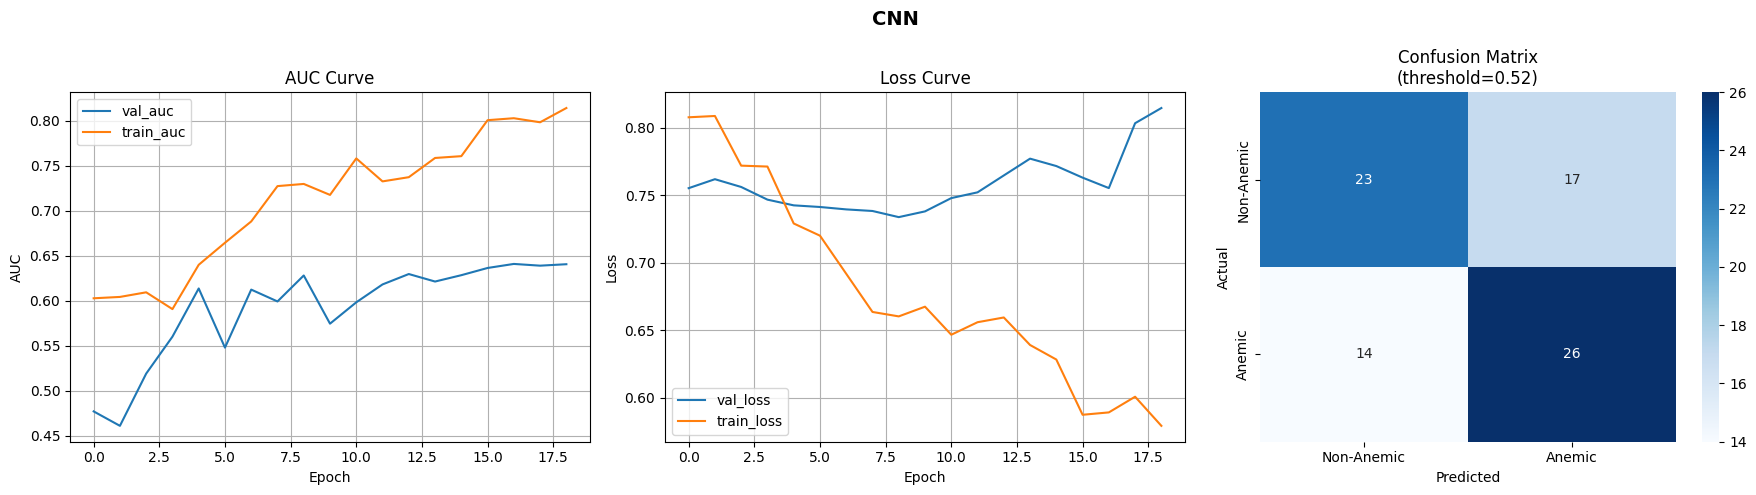

In [16]:
evaluate_model("CNN", model_1, history_1)

## CNN_2

In [17]:
model_2 = build_models(backbone="cnn2",mode="classification")

In [18]:
model_2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_2 = model_2.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 550s 35s/step - accuracy: 0.5462 - auc: 0.5755 - loss: 0.7807 - val_accuracy: 0.5063 - val_auc: 0.4112 - val_loss: 0.7543 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 306s 23s/step - accuracy: 0.5462 - auc: 0.5762 - loss: 0.7768 - val_accuracy: 0.4937 - val_auc: 0.4724 - val_loss: 0.7465 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 404s 34s/step - accuracy: 0.5625 - auc: 0.5967 - loss: 0.7402 - val_accuracy: 0.5063 - val_auc: 0.5535 - val_loss: 0.7431 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 552s 42s/step - accuracy: 0.6033 - auc: 0.6174 - loss: 0.7255 - val_accuracy: 0.4937 - val_auc: 0.6026 - val_loss: 0.7643 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 502s 42s/step - accuracy: 0.6005 - auc: 0.6338 - loss: 0.7245 - val_accuracy: 0.4937 - val_auc: 0.6375 - val_loss: 0.8009 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 277s 23s/step - 

CNN: Version 2
Metric                 Validation       Test
AUC                        0.4112     0.4106
Loss                       0.7543     0.7564

  Best Threshold (Youden): inf

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.50      1.00      0.67        40
      Anemic       0.00      0.00      0.00        40

    accuracy                           0.50        80
   macro avg       0.25      0.50      0.33        80
weighted avg       0.25      0.50      0.33        80



d:\venvs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\venvs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\venvs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


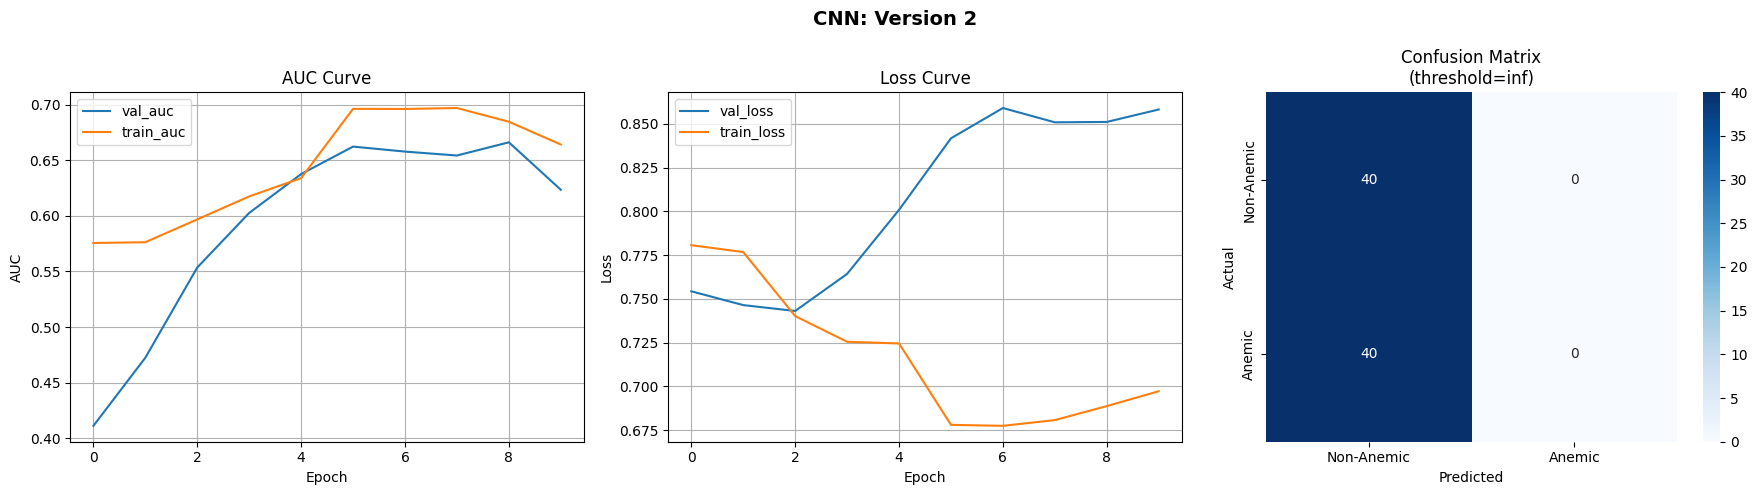

In [19]:
evaluate_model("CNN: Version 2", model_2, history_2)

## CNN_3

In [20]:
model_3 = build_models(backbone="cnn3",mode="classification")

In [21]:
model_3.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_3 = model_3.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 182s 6s/step - accuracy: 0.5489 - auc: 0.5474 - loss: 0.8604 - val_accuracy: 0.4937 - val_auc: 0.6558 - val_loss: 0.7594 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.5598 - auc: 0.5603 - loss: 0.8326 - val_accuracy: 0.5063 - val_auc: 0.6821 - val_loss: 0.7412 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 71s 6s/step - accuracy: 0.5897 - auc: 0.6430 - loss: 0.7284 - val_accuracy: 0.5063 - val_auc: 0.6756 - val_loss: 0.7396 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.5978 - auc: 0.6474 - loss: 0.7329 - val_accuracy: 0.4937 - val_auc: 0.6840 - val_loss: 0.7543 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.5978 - auc: 0.6390 - loss: 0.7254 - val_accuracy: 0.4937 - val_auc: 0.6792 - val_loss: 0.7821 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 73s 6s/step - accuracy: 0

CNN: Version 3
Metric                 Validation       Test
AUC                        0.6558     0.3525
Loss                       0.7594     0.7793

  Best Threshold (Youden): 0.4399

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.51      0.90      0.65        40
      Anemic       0.60      0.15      0.24        40

    accuracy                           0.53        80
   macro avg       0.56      0.53      0.45        80
weighted avg       0.56      0.53      0.45        80



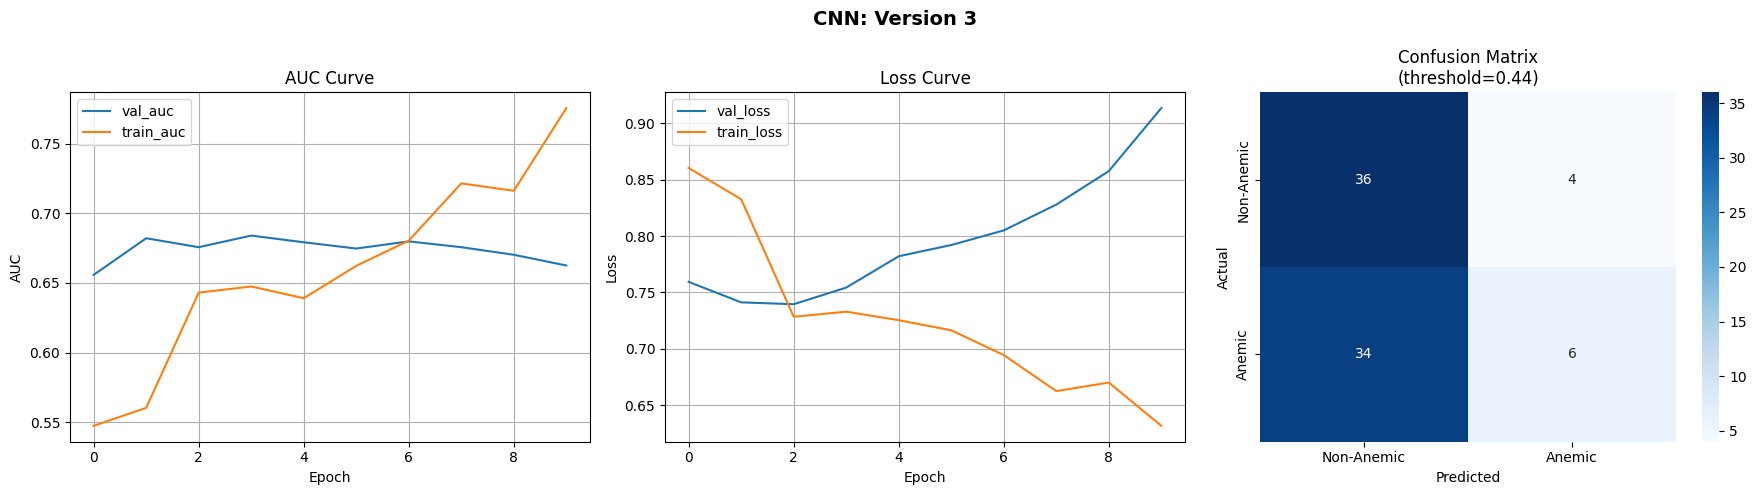

In [22]:
evaluate_model("CNN: Version 3", model_3, history_3)

## CNN_4

In [23]:
model_4 = build_models(backbone="cnn4",mode="classification")

In [24]:
model_4.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_4 = model_4.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.5163 - auc: 0.5457 - loss: 0.8329 - val_accuracy: 0.4937 - val_auc: 0.6340 - val_loss: 0.7701 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5245 - auc: 0.5318 - loss: 0.7926 - val_accuracy: 0.4937 - val_auc: 0.5843 - val_loss: 0.7666 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4918 - auc: 0.5075 - loss: 0.7857 - val_accuracy: 0.4937 - val_auc: 0.6247 - val_loss: 0.7679 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5652 - auc: 0.5803 - loss: 0.7504 - val_accuracy: 0.4937 - val_auc: 0.6038 - val_loss: 0.7570 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4837 - auc: 0.5087 - loss: 0.7818 - val_accuracy: 0.4937 - val_auc: 0.5481 - val_loss: 0.7523 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.

CNN: Version 4
Metric                 Validation       Test
AUC                        0.6340     0.4122
Loss                       0.7701     0.7813

  Best Threshold (Youden): 0.4548

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.50      1.00      0.67        40
      Anemic       0.00      0.00      0.00        40

    accuracy                           0.50        80
   macro avg       0.25      0.50      0.33        80
weighted avg       0.25      0.50      0.33        80



d:\venvs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\venvs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\venvs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


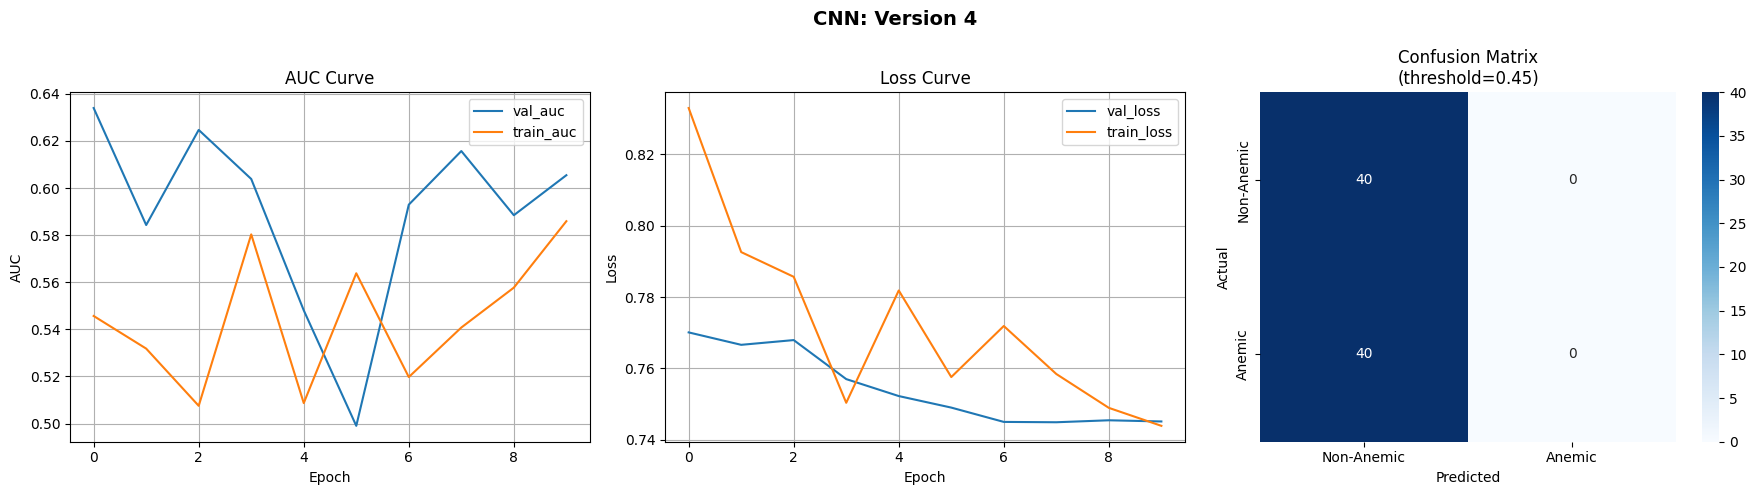

In [25]:
evaluate_model("CNN: Version 4", model_4, history_4)

## CNN_5

In [15]:
model_5 = build_models(backbone="cnn5",mode="classification")

In [16]:
model_5.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_5 = model_5.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 334s 5s/step - accuracy: 0.5576 - auc: 0.5681 - loss: 0.7569 - val_accuracy: 0.6329 - val_auc: 0.5369 - val_loss: 0.7323 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step - accuracy: 0.6315 - auc: 0.6754 - loss: 0.6962 - val_accuracy: 0.6203 - val_auc: 0.5628 - val_loss: 0.7283 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 305s 5s/step - accuracy: 0.6641 - auc: 0.6951 - loss: 0.6843 - val_accuracy: 0.6203 - val_auc: 0.5481 - val_loss: 0.7388 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1727s 30s/step - accuracy: 0.6745 - auc: 0.7011 - loss: 0.6759 - val_accuracy: 0.6203 - val_auc: 0.5651 - val_loss: 0.7219 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1542s 26s/step - accuracy: 0.6734 - auc: 0.7061 - loss: 0.6716 - val_accuracy: 0.6203 - val_auc: 0.6032 - val_loss: 0.7143 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - ac

CNN: Version 5
Metric                 Validation       Test
AUC                        0.6513     0.6231
Loss                       0.6692     0.6740

  Best Threshold (Youden): 0.4004

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.74      0.42      0.54        40
      Anemic       0.60      0.85      0.70        40

    accuracy                           0.64        80
   macro avg       0.67      0.64      0.62        80
weighted avg       0.67      0.64      0.62        80



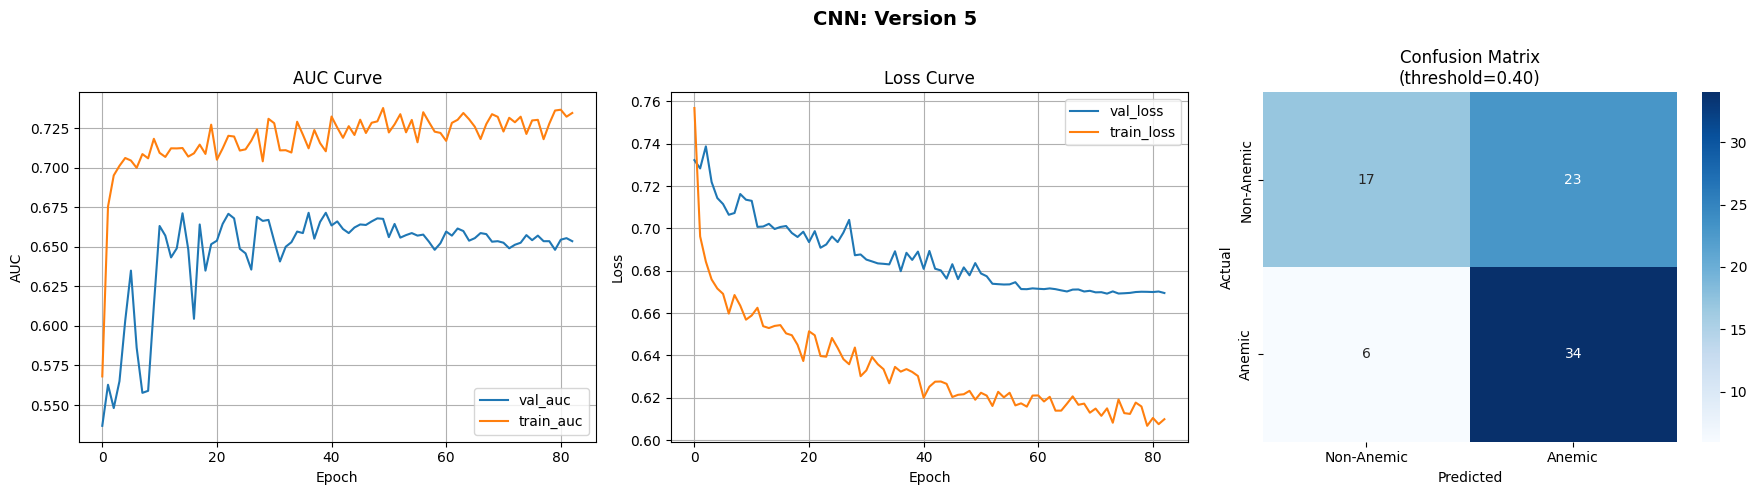

In [17]:
evaluate_model("CNN: Version 5", model_5, history_5)

## MobileNetV2

In [18]:
model_6 = build_models(backbone="mobilenetv2",mode="classification")

In [19]:
model_6.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_6 = model_6.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.5543 - auc: 0.5784 - loss: 0.7652 - val_accuracy: 0.6456 - val_auc: 0.6933 - val_loss: 0.7146 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 729ms/step - accuracy: 0.6125 - auc: 0.6631 - loss: 0.7128 - val_accuracy: 0.6203 - val_auc: 0.6667 - val_loss: 0.7055 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 713ms/step - accuracy: 0.6576 - auc: 0.7129 - loss: 0.6806 - val_accuracy: 0.6076 - val_auc: 0.6468 - val_loss: 0.7187 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 676ms/step - accuracy: 0.6745 - auc: 0.7233 - loss: 0.6688 - val_accuracy: 0.6329 - val_auc: 0.6571 - val_loss: 0.7127 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 681ms/step - accuracy: 0.6935 - auc: 0.7526 - loss: 0.6393 - val_accuracy: 0.6329 - val_auc: 0.6388 - val_loss: 0.7210 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 672ms/ste

MobileNet
Metric                 Validation       Test
AUC                        0.6933     0.6712
Loss                       0.7146     0.7171

  Best Threshold (Youden): 0.4768

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.70      0.65      0.68        40
      Anemic       0.67      0.72      0.70        40

    accuracy                           0.69        80
   macro avg       0.69      0.69      0.69        80
weighted avg       0.69      0.69      0.69        80



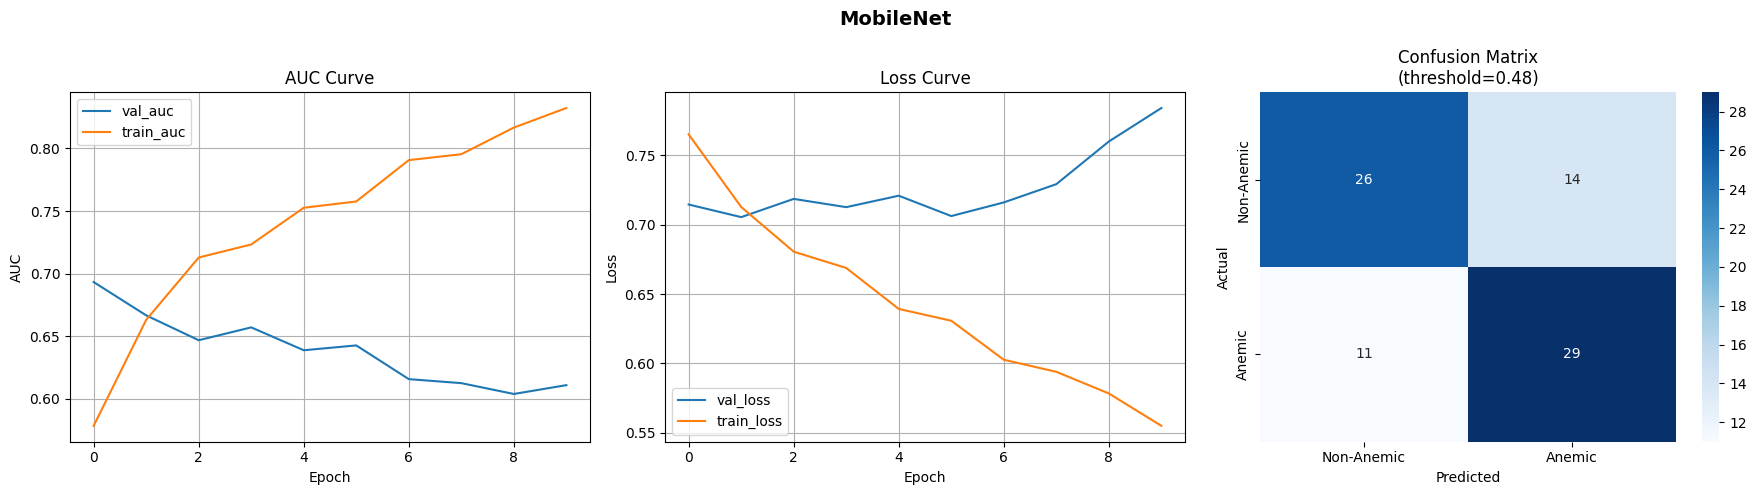

In [20]:
evaluate_model("MobileNet", model_6, history_6)

## EfficientNetB0

In [21]:
model_7 = build_models(backbone="efficientnetb0",mode="classification")

In [22]:
model_7.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_7 = model_7.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.5565 - auc: 0.5867 - loss: 0.8280 - val_accuracy: 0.5443 - val_auc: 0.6500 - val_loss: 0.8031 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6375 - auc: 0.6896 - loss: 0.7423 - val_accuracy: 0.6203 - val_auc: 0.6590 - val_loss: 0.7954 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7049 - auc: 0.7666 - loss: 0.6724 - val_accuracy: 0.6076 - val_auc: 0.6635 - val_loss: 0.8136 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7690 - auc: 0.8410 - loss: 0.5952 - val_accuracy: 0.5823 - val_auc: 0.6660 - val_loss: 0.8924 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8418 - auc: 0.9102 - loss: 0.4818 - val_accuracy: 0.5823 - val_auc: 0.6609 - val_loss: 1.0772 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0

EfficientNetB0
Metric                 Validation       Test
AUC                        0.6500     0.5966
Loss                       0.8031     0.8114

  Best Threshold (Youden): 0.6070

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.71      0.55      0.62        40
      Anemic       0.63      0.78      0.70        40

    accuracy                           0.66        80
   macro avg       0.67      0.66      0.66        80
weighted avg       0.67      0.66      0.66        80



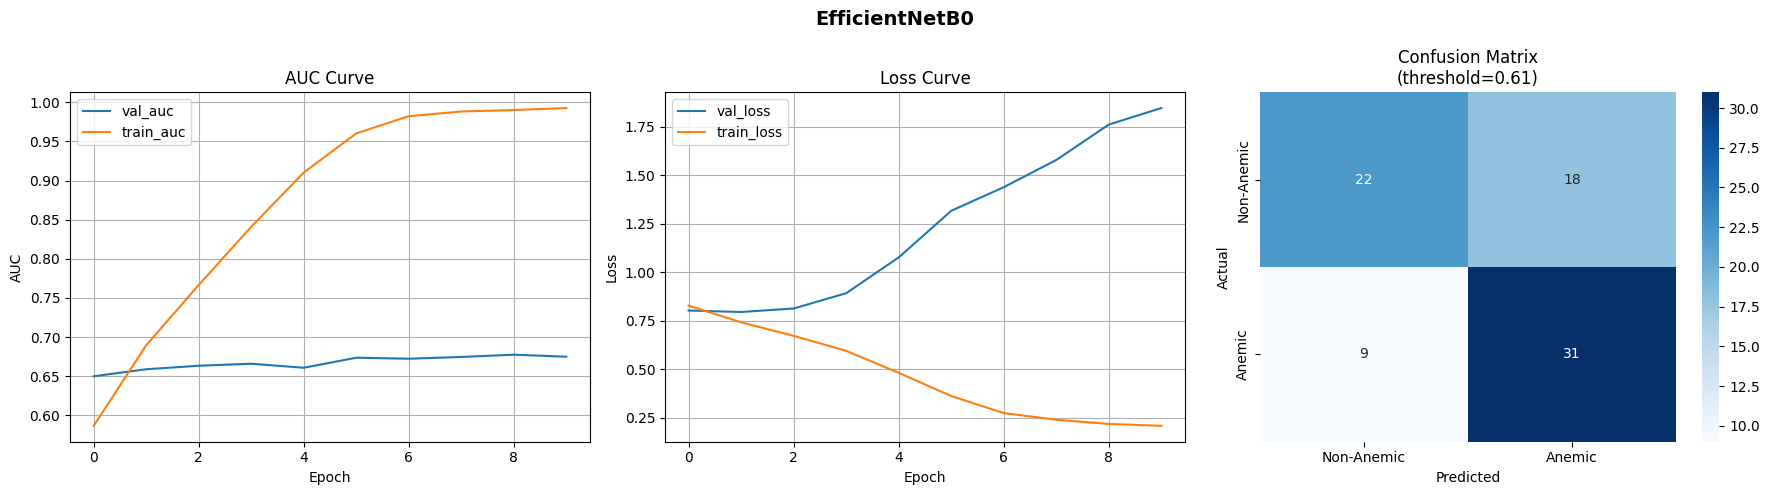

In [23]:
evaluate_model("EfficientNetB0", model_7, history_7)

## DenseNet121

In [24]:
model_8 = build_models(backbone="densenet121",mode="classification")

In [25]:
model_8.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_8 = model_8.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.5435 - auc: 0.5663 - loss: 0.7772 - val_accuracy: 0.4937 - val_auc: 0.5215 - val_loss: 0.7626 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.6163 - auc: 0.6653 - loss: 0.7099 - val_accuracy: 0.5063 - val_auc: 0.5625 - val_loss: 0.7431 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.6674 - auc: 0.7246 - loss: 0.6723 - val_accuracy: 0.6203 - val_auc: 0.6112 - val_loss: 0.7206 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.7147 - auc: 0.7878 - loss: 0.6110 - val_accuracy: 0.5949 - val_auc: 0.6369 - val_loss: 0.7315 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.7989 - auc: 0.8760 - loss: 0.5037 - val_accuracy: 0.5949 - val_auc: 0.6337 - val_loss: 0.8509 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accura

Densenet121
Metric                 Validation       Test
AUC                        0.5215     0.6078
Loss                       0.7626     0.7473

  Best Threshold (Youden): 0.3653

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.85      0.28      0.42        40
      Anemic       0.57      0.95      0.71        40

    accuracy                           0.61        80
   macro avg       0.71      0.61      0.56        80
weighted avg       0.71      0.61      0.56        80



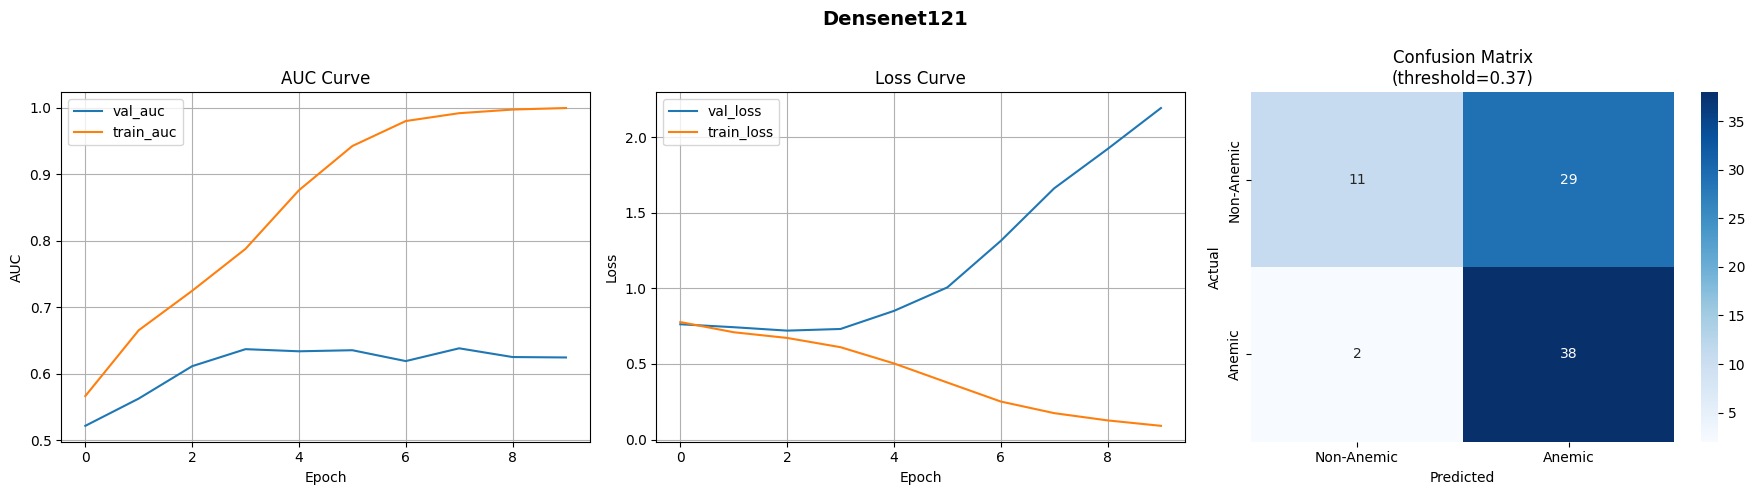

In [26]:
evaluate_model("Densenet121", model_8, history_8)

## DenseNet121 _ Version 2
Tuned attention head to 4

In [ ]:
model_9 = build_models(backbone="densenet121",mode="classification")

In [ ]:
model_9.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_9 = model_9.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 754s 8s/step - accuracy: 0.5967 - auc: 0.6365 - loss: 0.7301 - val_accuracy: 0.6076 - val_auc: 0.5907 - val_loss: 0.7510 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 353s 6s/step - accuracy: 0.7234 - auc: 0.7976 - loss: 0.6097 - val_accuracy: 0.5949 - val_auc: 0.6234 - val_loss: 0.7865 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 345s 6s/step - accuracy: 0.8016 - auc: 0.8762 - loss: 0.5045 - val_accuracy: 0.5949 - val_auc: 0.6135 - val_loss: 0.9507 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 276s 5s/step - accuracy: 0.9065 - auc: 0.9634 - loss: 0.3128 - val_accuracy: 0.6076 - val_auc: 0.6301 - val_loss: 1.1926 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.9538 - auc: 0.9917 - loss: 0.1861 - val_accuracy: 0.5823 - val_auc: 0.6151 - val_loss: 1.7429 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accura

Densenet121 _Version 02
Metric                 Validation       Test
AUC                        0.6606     0.6531
Loss                       2.2050     2.1437

  Best Threshold (Youden): 0.0132

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.66      0.57      0.61        40
      Anemic       0.62      0.70      0.66        40

    accuracy                           0.64        80
   macro avg       0.64      0.64      0.64        80
weighted avg       0.64      0.64      0.64        80



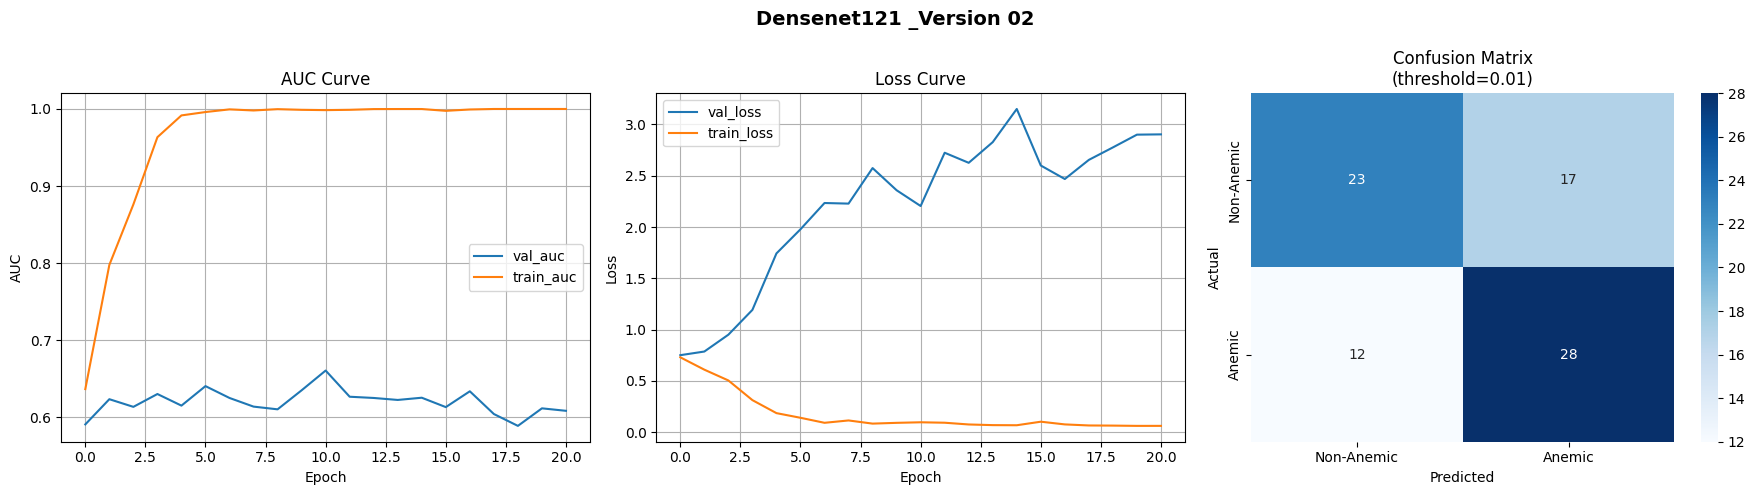

In [ ]:
evaluate_model("Densenet121 _Version 02", model_9, history_9)

## DenseNet169

In [27]:
model_10 =build_models(backbone="densenet169", mode="classification")

In [33]:
model_10.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
           tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)


history_10 = model_10.fit(
    x=[X_palm_train, X_nail_train, X_meta_train],
    y=y_label_train,
    validation_data=([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - accuracy: 0.6332 - auc: 0.6969 - loss: 0.6889 - val_accuracy: 0.6456 - val_auc: 0.6378 - val_loss: 0.7187 - learning_rate: 1.0000e-04
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 302s 5s/step - accuracy: 0.7337 - auc: 0.8126 - loss: 0.5854 - val_accuracy: 0.6456 - val_auc: 0.6333 - val_loss: 0.8023 - learning_rate: 1.0000e-04
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 364s 6s/step - accuracy: 0.7951 - auc: 0.8825 - loss: 0.4845 - val_accuracy: 0.6203 - val_auc: 0.6212 - val_loss: 0.9276 - learning_rate: 1.0000e-04
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 364s 6s/step - accuracy: 0.8978 - auc: 0.9618 - loss: 0.3179 - val_accuracy: 0.6456 - val_auc: 0.6272 - val_loss: 1.3687 - learning_rate: 1.0000e-04
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 305s 5s/step - accuracy: 0.9587 - auc: 0.9894 - loss: 0.1845 - val_accuracy: 0.6076 - val_auc: 0.6583 - val_loss: 1.7568 - learning_rate: 1.0000e-04
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 352s 6s/step - accuracy: 0.

densent
Metric                 Validation       Test
AUC                        0.6378     0.6503
Loss                       0.7187     0.7030

  Best Threshold (Youden): 0.3710

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.76      0.47      0.58        40
      Anemic       0.62      0.85      0.72        40

    accuracy                           0.66        80
   macro avg       0.69      0.66      0.65        80
weighted avg       0.69      0.66      0.65        80



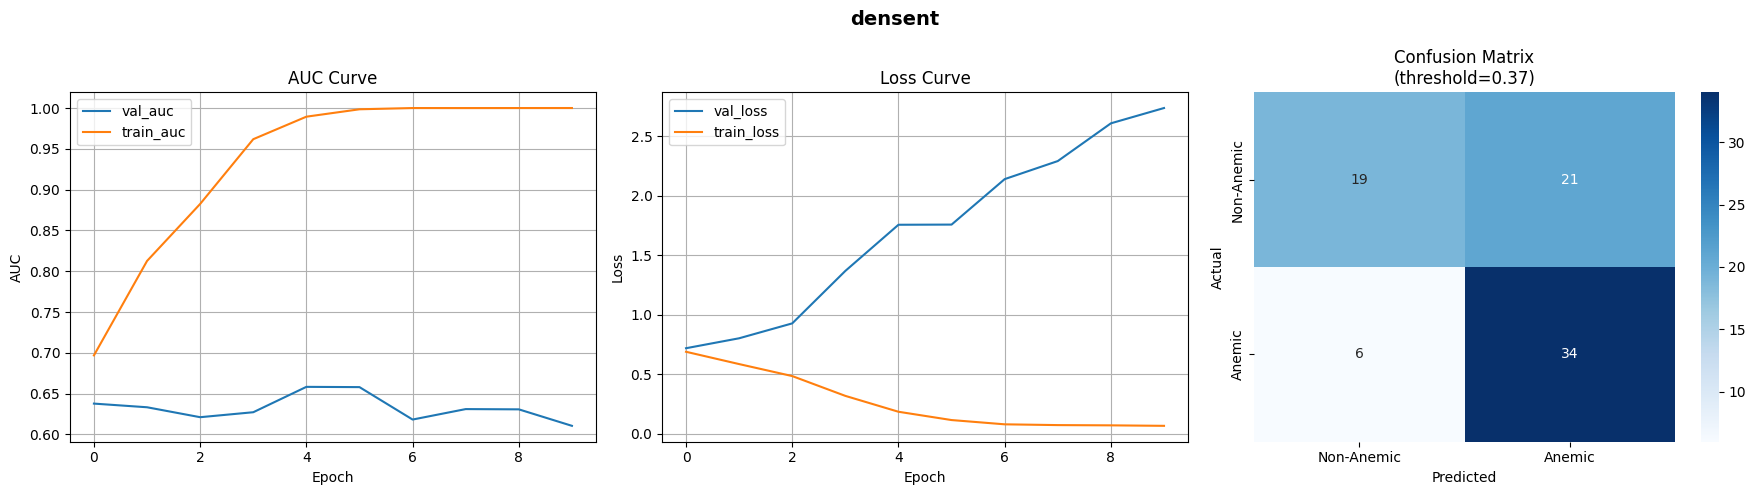

In [34]:
evaluate_model("densent",model_10,history_10)

## ResNet50

In [30]:
model_11 = build_models(backbone="resnet50",mode="classification")

In [31]:
model_11.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

history_11 = model_11.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y  = y_label_train,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_label_val),
    epochs=100, 
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.5832 - auc: 0.6105 - loss: 0.7560 - val_accuracy: 0.5570 - val_auc: 0.5686 - val_loss: 0.7506 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.7424 - auc: 0.8215 - loss: 0.5763 - val_accuracy: 0.5949 - val_auc: 0.5872 - val_loss: 1.2240 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 216s 4s/step - accuracy: 0.9060 - auc: 0.9575 - loss: 0.3288 - val_accuracy: 0.6076 - val_auc: 0.6506 - val_loss: 2.0399 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.9690 - auc: 0.9934 - loss: 0.1601 - val_accuracy: 0.5443 - val_auc: 0.5410 - val_loss: 2.1359 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.9745 - auc: 0.9930 - loss: 0.1508 - val_accuracy: 0.6076 - val_auc: 0.6429 - val_loss: 2.6143 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accura

ResNet50
Metric                 Validation       Test
AUC                        0.5686     0.6659
Loss                       0.7506     0.7110

  Best Threshold (Youden): 0.5650

 Classification Report:
              precision    recall  f1-score   support

  Non-Anemic       0.71      0.62      0.67        40
      Anemic       0.67      0.75      0.71        40

    accuracy                           0.69        80
   macro avg       0.69      0.69      0.69        80
weighted avg       0.69      0.69      0.69        80



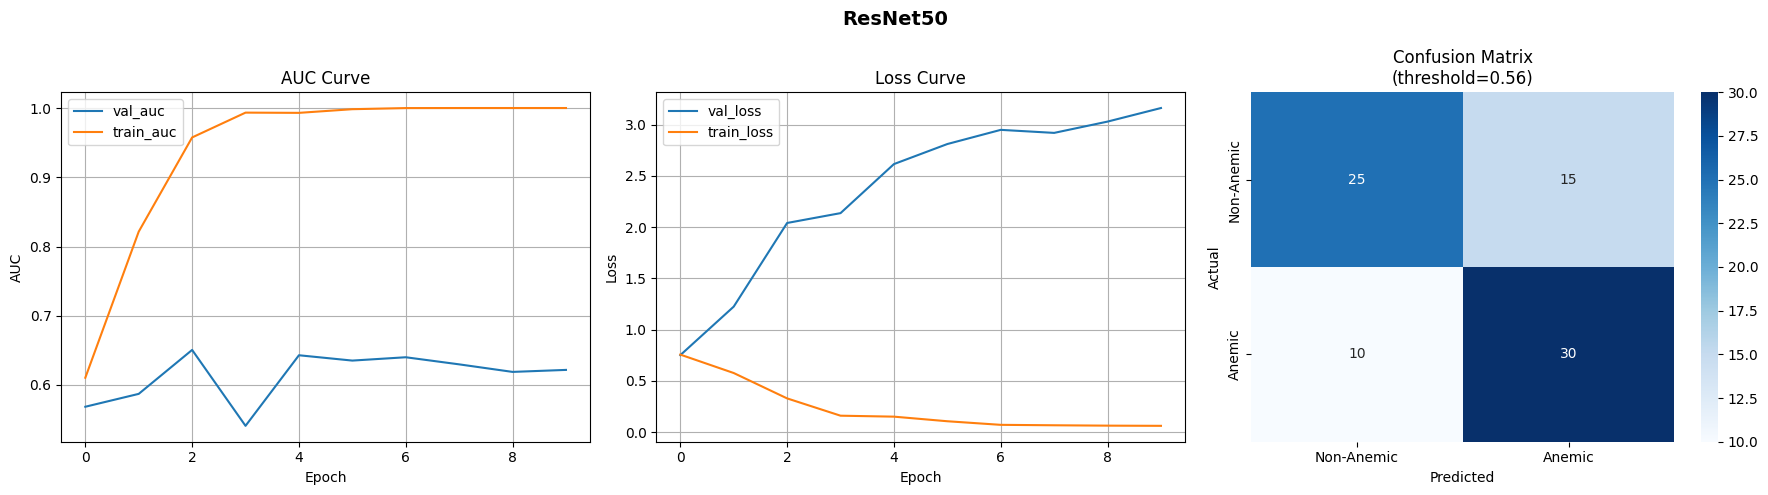

In [32]:
evaluate_model("ResNet50", model_11, history_11)